# 📚 NLP Phase 2 — Turning Text into Numbers
### Bag of Words | TF-IDF | N-grams | Your First Text Classifier
**Every line of code is explained. Zero confusion. Built for beginners.**

---

## 🧠 The Big Question of Phase 2

> **Computers only understand numbers. Text is not numbers. So how do we feed text to a machine learning model?**

Answer: We **convert text into numbers**. That is exactly what Phase 2 is about.

---

## 🗺️ What We Will Learn

| Topic | Simple Explanation |
|-------|-------------------|
| **2.1 Bag of Words** | Count how many times each word appears |
| **2.2 TF-IDF** | Score words by how important they are |
| **2.3 N-grams** | Capture word pairs and phrases, not just single words |
| **2.4 Text Classifier** | Build a spam detector using everything we learned |

---

## ⚡ How to use this notebook
- Press **Shift + Enter** to run each cell
- Read the markdown explanation BEFORE the code
- Every `#` line in the code explains that exact line
- Do not skip cells — each one builds on the previous

---
# 📦 CELL 1 — Install and Import Everything

We need these tools:
- **sklearn** (scikit-learn) → Has BoW, TF-IDF, and ML models built in
- **pandas** → For showing data as nice tables
- **matplotlib** → For drawing charts and graphs
- **nltk** → For text preprocessing (from Phase 1)

> Run this cell first. Wait for the ✅ message.

In [1]:
# Install the libraries we need
# scikit-learn (sklearn) is the most popular ML library in Python
# pandas helps us work with tables (like Excel in Python)
# matplotlib helps us draw charts
!pip install scikit-learn pandas matplotlib nltk --quiet

print("✅ Installation done!")

✅ Installation done!


In [2]:
# ---- Import the tools we need ----

# pandas is imported as 'pd' by convention (everyone uses this shortcut)
import pandas as pd

# matplotlib.pyplot is imported as 'plt' by convention
import matplotlib.pyplot as plt

# numpy handles numbers and arrays (math library)
import numpy as np

# From sklearn, import the text-to-numbers tools
# CountVectorizer = Bag of Words tool
from sklearn.feature_extraction.text import CountVectorizer

# TfidfVectorizer = TF-IDF tool
from sklearn.feature_extraction.text import TfidfVectorizer

# These are the Machine Learning models we will use
from sklearn.naive_bayes import MultinomialNB       # Naive Bayes classifier
from sklearn.linear_model import LogisticRegression # Logistic Regression classifier

# These help us split data and measure model performance
from sklearn.model_selection import train_test_split  # Split data into train/test
from sklearn.metrics import accuracy_score            # Measure how accurate our model is
from sklearn.metrics import classification_report     # Detailed performance report

# NLTK tools for text cleaning (we learned these in Phase 1)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re    # Regular expressions for cleaning text
import string  # Has list of punctuation characters

# Download NLTK data files
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("✅ All imports successful!")
print("We are ready to convert text into numbers!")

✅ All imports successful!
We are ready to convert text into numbers!


---
---
# 📦 TOPIC 2.1 — Bag of Words (BoW)

## What is Bag of Words?

Imagine you put all the words from a document into a BAG.
You don't care about the ORDER of words. You only care about **which words are present** and **how many times** each word appears.

**Example:**
- Sentence: `"I love cricket. Cricket is fun."`
- Bag: `{I: 1, love: 1, cricket: 2, is: 1, fun: 1}`

## How it Works — Step by Step

**Step 1:** Collect all unique words from ALL documents → This is called the **Vocabulary**

**Step 2:** For each document, count how many times each vocabulary word appears

**Step 3:** Each document becomes a **row of numbers** (one number per vocabulary word)

**Example with 3 documents:**
```
Doc 1: "I love cricket"
Doc 2: "I love football"
Doc 3: "cricket is better than football"

Vocabulary: [better, cricket, football, I, is, love, than]

          better  cricket  football  I  is  love  than
Doc 1:      0       1        0       1   0    1     0
Doc 2:      0       0        1       1   0    1     0
Doc 3:      1       1        1       0   1    0     1
```

Each row is now a **vector of numbers** — the computer can work with this!

In [3]:
# ============================================================
# Let's first build Bag of Words MANUALLY (without any library)
# This helps you understand EXACTLY what is happening inside
# ============================================================

# Our small collection of documents (called a 'corpus')
# corpus = a collection of text documents
corpus = [
    "I love cricket",
    "I love football",
    "cricket is better than football",
]

print("Our Documents (corpus):")
for i, doc in enumerate(corpus, start=1):
    print(f"  Document {i}: {doc}")
print()

# ---- Step 1: Build the Vocabulary ----
# We need to find ALL unique words across ALL documents

all_words = []  # Start with an empty list

# Loop through each document in the corpus
for doc in corpus:
    # Split the document into words using .split()
    words = doc.lower().split()  # .lower() makes everything lowercase first
    # Extend adds all words from 'words' into 'all_words'
    all_words.extend(words)

# set() removes duplicates — keeps only UNIQUE words
# sorted() arranges them alphabetically
vocabulary = sorted(set(all_words))

print(f"Vocabulary ({len(vocabulary)} unique words):")
print(f"  {vocabulary}")
print()

Our Documents (corpus):
  Document 1: I love cricket
  Document 2: I love football
  Document 3: cricket is better than football

Vocabulary (7 unique words):
  ['better', 'cricket', 'football', 'i', 'is', 'love', 'than']



In [4]:
# ---- Step 2: Count words in each document ----
# For each document, count how many times each vocabulary word appears

bow_matrix = []  # This will hold the count vectors for all documents

# Loop through each document
for doc in corpus:
    # Split this document into words
    words_in_doc = doc.lower().split()

    # Create a count vector for this document
    # For each word in the vocabulary, count how many times it appears in this doc
    count_vector = []
    for vocab_word in vocabulary:
        # .count() counts how many times vocab_word appears in words_in_doc
        count = words_in_doc.count(vocab_word)
        count_vector.append(count)  # Add this count to the vector

    # Add this document's count vector to the matrix
    bow_matrix.append(count_vector)

# ---- Step 3: Display as a table ----
# pd.DataFrame() creates a table from our data
# columns = vocabulary → each column is a word
# index = document names → each row is a document
bow_df = pd.DataFrame(
    bow_matrix,                                        # The data (our counts)
    columns=vocabulary,                                # Column names = vocabulary words
    index=['Document 1', 'Document 2', 'Document 3']  # Row names
)

print("Bag of Words Matrix (built manually):")
print("Each row = a document, Each column = a word, Each number = word count")
print()
print(bow_df.to_string())  # .to_string() prints the full table without cutting it off
print()
print("✅ You just built Bag of Words from scratch!")
print("   Now let's use sklearn to do it automatically.")

Bag of Words Matrix (built manually):
Each row = a document, Each column = a word, Each number = word count

            better  cricket  football  i  is  love  than
Document 1       0        1         0  1   0     1     0
Document 2       0        0         1  1   0     1     0
Document 3       1        1         1  0   1     0     1

✅ You just built Bag of Words from scratch!
   Now let's use sklearn to do it automatically.


In [5]:
# ============================================================
# Now let's use sklearn's CountVectorizer — it does everything automatically!
# CountVectorizer = the tool that builds Bag of Words for us
# ============================================================

# Our same corpus from before
corpus = [
    "I love cricket",
    "I love football",
    "cricket is better than football",
]

# Step 1: Create a CountVectorizer object
# Think of this as a machine that is ready to build BoW
# But it hasn't learned anything yet
vectorizer = CountVectorizer()

# Step 2: fit_transform() does TWO things in ONE line:
#   fit()      = Learn the vocabulary from the corpus
#   transform() = Convert each document into a count vector
# X is the result — a matrix of word counts
X = vectorizer.fit_transform(corpus)

# Step 3: See the vocabulary it learned
# get_feature_names_out() returns the list of words (vocabulary)
vocabulary = vectorizer.get_feature_names_out()
print("Vocabulary learned by CountVectorizer:")
print(vocabulary)
print()

# Step 4: Convert to a pandas DataFrame to display nicely
# X.toarray() converts the matrix into a regular numpy array (easier to read)
bow_sklearn_df = pd.DataFrame(
    X.toarray(),          # The word count matrix
    columns=vocabulary,   # Column names = vocabulary words
    index=['Doc 1', 'Doc 2', 'Doc 3']  # Row names
)

print("Bag of Words using CountVectorizer (sklearn):")
print(bow_sklearn_df.to_string())
print()
print("✅ Same result as manual! sklearn just does it faster.")

Vocabulary learned by CountVectorizer:
['better' 'cricket' 'football' 'is' 'love' 'than']

Bag of Words using CountVectorizer (sklearn):
       better  cricket  football  is  love  than
Doc 1       0        1         0   0     1     0
Doc 2       0        0         1   0     1     0
Doc 3       1        1         1   1     0     1

✅ Same result as manual! sklearn just does it faster.


In [6]:
# ============================================================
# Let's try BoW on a more realistic example — movie reviews!
# ============================================================

# 6 short movie reviews with their labels
# Label 1 = Positive review
# Label 0 = Negative review
reviews = [
    "This movie is amazing and wonderful",      # Positive
    "I loved this film it was great",           # Positive
    "Fantastic movie best film ever",           # Positive
    "This movie is terrible and boring",        # Negative
    "I hated this film it was awful",           # Negative
    "Worst movie ever complete waste of time",  # Negative
]

labels = [1, 1, 1, 0, 0, 0]  # 1 = positive, 0 = negative

# Create and fit the vectorizer
vec = CountVectorizer()
X_reviews = vec.fit_transform(reviews)

# Create a DataFrame to display nicely
vocab = vec.get_feature_names_out()
df_reviews = pd.DataFrame(
    X_reviews.toarray(),
    columns=vocab
)

# Add the labels as a column so we can see them
# map() converts 1 → 'POSITIVE' and 0 → 'NEGATIVE' for readability
df_reviews['LABEL'] = ['POSITIVE' if l == 1 else 'NEGATIVE' for l in labels]

print("BoW for Movie Reviews:")
print("Each row = one review, Numbers = word counts")
print()
print(df_reviews.to_string())
print()
print(f"Total vocabulary size: {len(vocab)} unique words")

BoW for Movie Reviews:
Each row = one review, Numbers = word counts

   amazing  and  awful  best  boring  complete  ever  fantastic  film  great  hated  is  it  loved  movie  of  terrible  this  time  was  waste  wonderful  worst     LABEL
0        1    1      0     0       0         0     0          0     0      0      0   1   0      0      1   0         0     1     0    0      0          1      0  POSITIVE
1        0    0      0     0       0         0     0          0     1      1      0   0   1      1      0   0         0     1     0    1      0          0      0  POSITIVE
2        0    0      0     1       0         0     1          1     1      0      0   0   0      0      1   0         0     0     0    0      0          0      0  POSITIVE
3        0    1      0     0       1         0     0          0     0      0      0   1   0      0      1   0         1     1     0    0      0          0      0  NEGATIVE
4        0    0      1     0       0         0     0          0     1  

In [7]:
# ============================================================
# PROBLEMS with Bag of Words
# ============================================================
# BoW has 3 main problems. Let's understand them with examples.

print("=" * 55)
print("  PROBLEMS WITH BAG OF WORDS")
print("=" * 55)

# --- Problem 1: No word order ---
print("\n❌ PROBLEM 1: BoW ignores word ORDER")
sent_a = "The dog bit the man"
sent_b = "The man bit the dog"
# These two sentences mean VERY different things
# But BoW gives them the EXACT SAME vector!
vec_test = CountVectorizer()
result = vec_test.fit_transform([sent_a, sent_b]).toarray()
print(f"  Sentence A: '{sent_a}'")
print(f"  Sentence B: '{sent_b}'")
print(f"  Both sentences give same BoW vector: {result[0] == result[1]}")
print(f"  Vector A: {result[0]}")
print(f"  Vector B: {result[1]}")

# --- Problem 2: Common words dominate ---
print("\n❌ PROBLEM 2: Very common words dominate")
print("  Words like 'the', 'is', 'a' appear everywhere")
print("  They get HIGH counts but carry NO meaning")
print("  Example: 'the' appears in every document but tells us nothing special")

# --- Problem 3: Large sparse matrix ---
print("\n❌ PROBLEM 3: Vocabulary becomes HUGE")
print("  If you have 10,000 documents with 50,000 unique words,")
print("  your matrix is 10,000 × 50,000 = 500 MILLION cells!")
print("  Most cells are 0 (most documents don't contain most words)")
print("  This is called a SPARSE matrix — wastes memory")

print("\n💡 SOLUTION: TF-IDF — our next topic!")
print("   TF-IDF fixes Problem 2 by scoring words by IMPORTANCE, not just count")

  PROBLEMS WITH BAG OF WORDS

❌ PROBLEM 1: BoW ignores word ORDER
  Sentence A: 'The dog bit the man'
  Sentence B: 'The man bit the dog'
  Both sentences give same BoW vector: [ True  True  True  True]
  Vector A: [1 1 1 2]
  Vector B: [1 1 1 2]

❌ PROBLEM 2: Very common words dominate
  Words like 'the', 'is', 'a' appear everywhere
  They get HIGH counts but carry NO meaning
  Example: 'the' appears in every document but tells us nothing special

❌ PROBLEM 3: Vocabulary becomes HUGE
  If you have 10,000 documents with 50,000 unique words,
  your matrix is 10,000 × 50,000 = 500 MILLION cells!
  Most cells are 0 (most documents don't contain most words)
  This is called a SPARSE matrix — wastes memory

💡 SOLUTION: TF-IDF — our next topic!
   TF-IDF fixes Problem 2 by scoring words by IMPORTANCE, not just count


---
---
# ⭐ TOPIC 2.2 — TF-IDF
## (Term Frequency — Inverse Document Frequency)

## The Problem TF-IDF Solves
In Bag of Words, the word `"the"` might appear 100 times in a document and get a high count.
But `"the"` is useless — it appears in EVERY document. It's not special.

TF-IDF says: **"A word is important if it appears often in THIS document but NOT in other documents."**

---

## TF-IDF = TF × IDF

### TF (Term Frequency)
How often does this word appear in THIS document?
```
TF = (Number of times word appears in document) / (Total words in document)
```

### IDF (Inverse Document Frequency)
How RARE is this word across ALL documents?
- If a word appears in ALL documents → IDF is LOW (word is common, not special)
- If a word appears in FEW documents → IDF is HIGH (word is rare, very special!)
```
IDF = log(Total documents / Number of documents containing this word)
```

### Final Score
```
TF-IDF = TF × IDF
```
- High TF-IDF → Word is IMPORTANT for this specific document
- Low TF-IDF → Word is either rare in doc OR common everywhere

---

## Simple Example
```
Document: "Cricket is the best sport. India loves cricket."
All documents: 100 cricket articles

Word 'cricket': appears often in THIS doc AND in many others → medium TF-IDF
Word 'the':     appears often in THIS doc BUT in ALL others → LOW TF-IDF ← good!
Word 'Dhoni':   appears rarely in this doc but in VERY FEW others → HIGH TF-IDF
```

In [8]:
# ============================================================
# Let's calculate TF-IDF MANUALLY first — so you understand every formula
# ============================================================

import math  # We need math.log() for the IDF formula

# Our small corpus — 3 documents
corpus = [
    "the cat sat on the mat",          # Document 1
    "the cat sat on the hat",          # Document 2
    "the dog played in the garden",    # Document 3
]

print("Our Corpus:")
for i, doc in enumerate(corpus, 1):
    print(f"  Doc {i}: {doc}")
print()

# Let's calculate TF-IDF for the word 'cat' in Document 1
target_word = 'cat'
target_doc = corpus[0]  # This is Document 1

# ---- Calculate TF ----
# TF = count of word in document / total words in document

words_in_doc1 = target_doc.split()  # Split doc 1 into words

# Count how many times 'cat' appears in doc 1
word_count_in_doc = words_in_doc1.count(target_word)

# Total number of words in doc 1
total_words_in_doc = len(words_in_doc1)

# TF formula
TF = word_count_in_doc / total_words_in_doc

print(f"Calculating TF-IDF for word: '{target_word}' in Document 1")
print(f"\n--- TF (Term Frequency) ---")
print(f"  Word count in doc 1     : {word_count_in_doc}")
print(f"  Total words in doc 1    : {total_words_in_doc}")
print(f"  TF = {word_count_in_doc} / {total_words_in_doc} = {TF:.4f}")
print()

Our Corpus:
  Doc 1: the cat sat on the mat
  Doc 2: the cat sat on the hat
  Doc 3: the dog played in the garden

Calculating TF-IDF for word: 'cat' in Document 1

--- TF (Term Frequency) ---
  Word count in doc 1     : 1
  Total words in doc 1    : 6
  TF = 1 / 6 = 0.1667



In [9]:
# ---- Calculate IDF ----
# IDF = log(Total documents / Number of documents that contain this word)

total_documents = len(corpus)  # We have 3 documents

# Count how many documents contain the target word
# We go through each document and check if the word is in it
docs_containing_word = 0  # Start at 0
for doc in corpus:
    if target_word in doc.split():  # If the word is in this document
        docs_containing_word += 1   # Add 1 to our count

# IDF formula — we use +1 inside log to avoid division by zero
# log() is the mathematical logarithm function
IDF = math.log(total_documents / docs_containing_word)

print(f"--- IDF (Inverse Document Frequency) ---")
print(f"  Total documents          : {total_documents}")
print(f"  Documents with '{target_word}'  : {docs_containing_word}")
print(f"  IDF = log({total_documents}/{docs_containing_word}) = {IDF:.4f}")
print()

# ---- Final TF-IDF score ----
TFIDF = TF * IDF

print(f"--- Final TF-IDF Score ---")
print(f"  TF-IDF = TF × IDF = {TF:.4f} × {IDF:.4f} = {TFIDF:.4f}")
print()

# Now compare with a very common word like 'the'
the_count_in_doc = words_in_doc1.count('the')
TF_the = the_count_in_doc / total_words_in_doc

docs_with_the = sum(1 for doc in corpus if 'the' in doc.split())
IDF_the = math.log(total_documents / docs_with_the) if docs_with_the < total_documents else 0

TFIDF_the = TF_the * IDF_the

print(f"Comparison:")
print(f"  'cat' TF-IDF score : {TFIDF:.4f}  ← higher, more meaningful")
print(f"  'the' TF-IDF score : {TFIDF_the:.4f}   ← lower, less meaningful")
print()
print("✅ TF-IDF correctly gives 'the' a low score because it appears in ALL documents!")

--- IDF (Inverse Document Frequency) ---
  Total documents          : 3
  Documents with 'cat'  : 2
  IDF = log(3/2) = 0.4055

--- Final TF-IDF Score ---
  TF-IDF = TF × IDF = 0.1667 × 0.4055 = 0.0676

Comparison:
  'cat' TF-IDF score : 0.0676  ← higher, more meaningful
  'the' TF-IDF score : 0.0000   ← lower, less meaningful

✅ TF-IDF correctly gives 'the' a low score because it appears in ALL documents!


In [10]:
# ============================================================
# Now let's use sklearn's TfidfVectorizer — does it all automatically!
# Usage is EXACTLY the same as CountVectorizer — just a different class name
# ============================================================

# Our corpus of movie reviews
corpus = [
    "the cat sat on the mat",
    "the cat sat on the hat",
    "the dog played in the garden",
]

# Step 1: Create a TfidfVectorizer object
# This is a machine that will calculate TF-IDF scores for us
tfidf_vectorizer = TfidfVectorizer()

# Step 2: fit_transform() — Learn from the corpus and convert to TF-IDF matrix
# Same as CountVectorizer but values are TF-IDF SCORES instead of raw counts
X_tfidf = tfidf_vectorizer.fit_transform(corpus)

# Step 3: Get the vocabulary
vocab = tfidf_vectorizer.get_feature_names_out()

# Step 4: Create a DataFrame to display nicely
# round(2) rounds all numbers to 2 decimal places
tfidf_df = pd.DataFrame(
    X_tfidf.toarray().round(3),  # .round(3) = round to 3 decimal places
    columns=vocab,
    index=['Doc 1', 'Doc 2', 'Doc 3']
)

print("TF-IDF Matrix (higher score = more important word for that document):")
print()
print(tfidf_df.to_string())
print()
print("Notice: 'the' gets a LOW score everywhere (it's in all docs)")
print("        'mat', 'hat', 'garden' get HIGH scores (unique to one doc)")

TF-IDF Matrix (higher score = more important word for that document):

         cat    dog  garden    hat     in    mat     on  played    sat    the
Doc 1  0.374  0.000   0.000  0.000  0.000  0.492  0.374   0.000  0.374  0.581
Doc 2  0.374  0.000   0.000  0.492  0.000  0.000  0.374   0.000  0.374  0.581
Doc 3  0.000  0.431   0.431  0.000  0.431  0.000  0.000   0.431  0.000  0.509

Notice: 'the' gets a LOW score everywhere (it's in all docs)
        'mat', 'hat', 'garden' get HIGH scores (unique to one doc)


In [11]:
# ============================================================
# Side-by-side comparison: BoW vs TF-IDF
# ============================================================

sample_corpus = [
    "the cricket match was exciting and India won the match",
    "India played great cricket in the world cup tournament",
    "the football match was boring but the crowd enjoyed",
]

# Build BoW
bow_vec = CountVectorizer()
X_bow = bow_vec.fit_transform(sample_corpus)
bow_df = pd.DataFrame(
    X_bow.toarray(),
    columns=bow_vec.get_feature_names_out(),
    index=['Doc 1', 'Doc 2', 'Doc 3']
)

# Build TF-IDF
tfidf_vec = TfidfVectorizer()
X_tfidf = tfidf_vec.fit_transform(sample_corpus)
tfidf_df = pd.DataFrame(
    X_tfidf.toarray().round(3),
    columns=tfidf_vec.get_feature_names_out(),
    index=['Doc 1', 'Doc 2', 'Doc 3']
)

print("=" * 60)
print("BAG OF WORDS (raw word counts):")
print("=" * 60)
print(bow_df.to_string())
print()

print("=" * 60)
print("TF-IDF (importance scores):")
print("=" * 60)
print(tfidf_df.to_string())
print()

# Show specific comparison for 'the'
print("--- Comparison for word 'the' ---")
print("  BoW: 'the' gets count of 2 in Doc 1 (looks important)")
print("  TF-IDF: 'the' gets very low score (correctly shown as unimportant)")
print()
print("✅ TF-IDF is SMARTER than BoW for most NLP tasks!")

BAG OF WORDS (raw word counts):
       and  boring  but  cricket  crowd  cup  enjoyed  exciting  football  great  in  india  match  played  the  tournament  was  won  world
Doc 1    1       0    0        1      0    0        0         1         0      0   0      1      2       0    2           0    1    1      0
Doc 2    0       0    0        1      0    1        0         0         0      1   1      1      0       1    1           1    0    0      1
Doc 3    0       1    1        0      1    0        1         0         1      0   0      0      1       0    2           0    1    0      0

TF-IDF (importance scores):
         and  boring    but  cricket  crowd    cup  enjoyed  exciting  football  great     in  india  match  played    the  tournament    was    won  world
Doc 1  0.344   0.000  0.000    0.262  0.000  0.000    0.000     0.344     0.000  0.000  0.000  0.262  0.523   0.000  0.406       0.000  0.262  0.344  0.000
Doc 2  0.000   0.000  0.000    0.278  0.000  0.365    0.000    

---
---
# 🔤 TOPIC 2.3 — N-grams

## The Problem with Single Words

Both BoW and TF-IDF treat each word separately.
But sometimes, the COMBINATION of words is what matters!

**Example:**
- `"not good"` → BoW sees `not` and `good` separately
- But together `"not good"` means the OPPOSITE of `"good"`!
- BoW misses this completely!

## What are N-grams?

N-grams are **sequences of N consecutive words**.

```
Sentence: "I love playing cricket"

1-gram (Unigram):  ["I", "love", "playing", "cricket"]
2-gram (Bigram):   ["I love", "love playing", "playing cricket"]
3-gram (Trigram):  ["I love playing", "love playing cricket"]
```

By using bigrams and trigrams, we capture **phrases and context**!

In [12]:
# ============================================================
# Let's build N-grams MANUALLY first
# ============================================================

def get_ngrams(text, n):
    """
    This function creates n-grams from a text.

    Parameters:
        text (str) : The input sentence
        n (int)    : The size of each gram (1=unigram, 2=bigram, 3=trigram)

    Returns:
        list: A list of n-grams
    """
    # First split the text into individual words
    words = text.lower().split()

    # Create n-grams using a list comprehension
    # range(len(words) - n + 1) gives us the starting positions for each n-gram
    # Example: for "I love cricket" with n=2:
    #   positions: 0, 1  (we can start a bigram at positions 0 and 1)
    #   position 0: words[0:2] = ["I", "love"]     → "I love"
    #   position 1: words[1:3] = ["love", "cricket"] → "love cricket"
    ngrams = []
    for i in range(len(words) - n + 1):
        # words[i:i+n] gives a slice of n words starting at position i
        gram = words[i : i + n]
        # ' '.join(gram) joins the list of words into a single string with space
        ngrams.append(' '.join(gram))

    return ngrams


# Test our function
sentence = "I love playing cricket with my friends"

print(f"Sentence: '{sentence}'")
print()

# Get unigrams (n=1) — just individual words
unigrams = get_ngrams(sentence, n=1)
print(f"Unigrams (n=1): {unigrams}")
print()

# Get bigrams (n=2) — pairs of consecutive words
bigrams = get_ngrams(sentence, n=2)
print(f"Bigrams  (n=2): {bigrams}")
print()

# Get trigrams (n=3) — triplets of consecutive words
trigrams = get_ngrams(sentence, n=3)
print(f"Trigrams (n=3): {trigrams}")

Sentence: 'I love playing cricket with my friends'

Unigrams (n=1): ['i', 'love', 'playing', 'cricket', 'with', 'my', 'friends']

Bigrams  (n=2): ['i love', 'love playing', 'playing cricket', 'cricket with', 'with my', 'my friends']

Trigrams (n=3): ['i love playing', 'love playing cricket', 'playing cricket with', 'cricket with my', 'with my friends']


In [13]:
# ============================================================
# Using CountVectorizer with N-grams
# We just add ONE parameter: ngram_range=(min, max)
# ============================================================

reviews = [
    "the movie is not good",     # Negative — 'not good' is important!
    "the movie is very good",    # Positive — 'very good' is important!
    "the film is not bad",       # Positive — 'not bad' means good!
]

print("Reviews:")
for i, r in enumerate(reviews, 1):
    print(f"  {i}: {r}")
print()

# --- Unigram BoW (what we did before) ---
# ngram_range=(1,1) means only use single words
unigram_vec = CountVectorizer(ngram_range=(1, 1))
X_uni = unigram_vec.fit_transform(reviews)
uni_df = pd.DataFrame(
    X_uni.toarray(),
    columns=unigram_vec.get_feature_names_out(),
    index=['Review 1', 'Review 2', 'Review 3']
)

# --- Bigram BoW ---
# ngram_range=(2,2) means only use word PAIRS
bigram_vec = CountVectorizer(ngram_range=(2, 2))
X_bi = bigram_vec.fit_transform(reviews)
bi_df = pd.DataFrame(
    X_bi.toarray(),
    columns=bigram_vec.get_feature_names_out(),
    index=['Review 1', 'Review 2', 'Review 3']
)

# --- Unigram + Bigram combined ---
# ngram_range=(1,2) means use BOTH single words AND word pairs
uni_bi_vec = CountVectorizer(ngram_range=(1, 2))
X_uni_bi = uni_bi_vec.fit_transform(reviews)
uni_bi_df = pd.DataFrame(
    X_uni_bi.toarray(),
    columns=uni_bi_vec.get_feature_names_out(),
    index=['Review 1', 'Review 2', 'Review 3']
)

print("UNIGRAMS only (single words):")
print(uni_df.to_string())
print("\n'not' and 'good' are separate — model can't understand 'not good'")

print("\n" + "=" * 60)
print("BIGRAMS only (word pairs):")
print(bi_df.to_string())
print("\nNow we can see 'not good' vs 'very good' vs 'not bad' as features!")

print("\n" + "=" * 60)
print("UNIGRAMS + BIGRAMS combined (best of both):")
print(uni_bi_df.to_string())
print("\n✅ ngram_range=(1,2) is the most commonly used setting in NLP!")

Reviews:
  1: the movie is not good
  2: the movie is very good
  3: the film is not bad

UNIGRAMS only (single words):
          bad  film  good  is  movie  not  the  very
Review 1    0     0     1   1      1    1    1     0
Review 2    0     0     1   1      1    0    1     1
Review 3    1     1     0   1      0    1    1     0

'not' and 'good' are separate — model can't understand 'not good'

BIGRAMS only (word pairs):
          film is  is not  is very  movie is  not bad  not good  the film  the movie  very good
Review 1        0       1        0         1        0         1         0          1          0
Review 2        0       0        1         1        0         0         0          1          1
Review 3        1       1        0         0        1         0         1          0          0

Now we can see 'not good' vs 'very good' vs 'not bad' as features!

UNIGRAMS + BIGRAMS combined (best of both):
          bad  film  film is  good  is  is not  is very  movie  movie is  no

In [14]:
# ============================================================
# Why N-grams matter — the 'not good' problem
# ============================================================

print("The 'not good' Problem — Why Unigrams Fail")
print("=" * 50)
print()

pos_sentence = "This movie is very good"   # Positive
neg_sentence = "This movie is not good"    # Negative

# With UNIGRAMS:
# Both sentences contain the word 'good'
# A model using unigrams might classify BOTH as positive!

# With BIGRAMS:
# Positive sentence has 'very good'
# Negative sentence has 'not good'
# These are completely different features — model can now tell them apart!

bigram_test = CountVectorizer(ngram_range=(1, 2))
X_test = bigram_test.fit_transform([pos_sentence, neg_sentence])
test_df = pd.DataFrame(
    X_test.toarray(),
    columns=bigram_test.get_feature_names_out(),
    index=['POSITIVE', 'NEGATIVE']
)

print(f"Positive: '{pos_sentence}'")
print(f"Negative: '{neg_sentence}'")
print()
print("With Unigrams + Bigrams:")
print(test_df.to_string())
print()
print("✅ Notice: 'not good' and 'very good' are now DIFFERENT features!")
print("   The model can now correctly distinguish positive vs negative.")

The 'not good' Problem — Why Unigrams Fail

Positive: 'This movie is very good'
Negative: 'This movie is not good'

With Unigrams + Bigrams:
          good  is  is not  is very  movie  movie is  not  not good  this  this movie  very  very good
POSITIVE     1   1       0        1      1         1    0         0     1           1     1          1
NEGATIVE     1   1       1        0      1         1    1         1     1           1     0          0

✅ Notice: 'not good' and 'very good' are now DIFFERENT features!
   The model can now correctly distinguish positive vs negative.


---
---
# 🤖 TOPIC 2.4 — Build Your First Text Classifier!
## Spam Detector — Ham or Spam?

Now we use EVERYTHING we learned to build a real ML model!

**The Task:** Given an SMS message, classify it as:
- **SPAM** = Unwanted promotional message ("You won a prize! Call now!")
- **HAM** = Legitimate message ("Hey, are you coming for dinner?")

## The Plan
```
Raw SMS Text
    ↓
Clean the text (Phase 1 skills)
    ↓
Convert to TF-IDF vectors (Phase 2 skills)
    ↓
Train a Naive Bayes model
    ↓
Test on new messages
    ↓
Spam or Ham? ✅
```

In [15]:
# ============================================================
# STEP 1: Create our dataset
# In a real project you would load a CSV file
# Here we create a small dataset manually to understand the concept
# ============================================================

# Our SMS messages
messages = [
    # SPAM messages (label = 1)
    "WINNER!! You have been selected for a cash prize of Rs 50000. Call now!",
    "FREE entry to win a brand new iPhone. Click the link to claim your prize",
    "Congratulations! You won a lottery worth 1 crore. Reply YES to claim",
    "URGENT: Your account will be closed. Verify now by clicking this link",
    "You have won a FREE holiday trip to Goa! Call 9999999999 to claim",
    "Get 50% off on all products today only! Limited offer. Buy now!",
    "Your loan is approved for Rs 2 lakhs. No documents needed. Call now",
    "Earn Rs 5000 daily from home. Easy work. No experience needed. WhatsApp now",
    "FREE SIM card recharge of Rs 500. Click here to activate",
    "Special offer! Get insurance coverage for just Rs 99 per month. Act fast",

    # HAM messages (label = 0)
    "Hey are you coming for dinner tonight?",
    "Can you please call me when you get a chance",
    "The meeting has been rescheduled to 3pm tomorrow",
    "I will be late by 20 minutes, stuck in traffic",
    "Happy birthday! Hope you have a wonderful day",
    "Did you finish the homework? I need help with question 5",
    "Let us meet at the coffee shop at 6pm",
    "Mom says she will pick you up from college today",
    "The cricket match starts at 7. Are you watching?",
    "Can you send me the notes from today's lecture",
]

# Labels: 1 = SPAM, 0 = HAM (normal message)
labels = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1,   # First 10 are SPAM
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0]    # Last 10 are HAM

# Create a pandas DataFrame to organize our data as a table
# pd.DataFrame() creates a table
# 'Message' and 'Label' are column names
df = pd.DataFrame({
    'Message': messages,  # Column 1: the actual SMS text
    'Label': labels       # Column 2: 1 for spam, 0 for ham
})

# Add a readable label column — shows 'SPAM' or 'HAM' instead of 1 and 0
# apply() runs a function on each row of the column
# lambda x: ... is a one-line function: if x is 1 return 'SPAM', else return 'HAM'
df['Type'] = df['Label'].apply(lambda x: 'SPAM' if x == 1 else 'HAM')

print("Our Dataset:")
print(f"Total messages: {len(df)}")
print(f"SPAM messages : {sum(labels)}")
print(f"HAM messages  : {len(labels) - sum(labels)}")
print()

# Display first few rows of the table
# .head(6) shows the first 6 rows
print(df[['Type', 'Message']].head(6).to_string())

Our Dataset:
Total messages: 20
SPAM messages : 10
HAM messages  : 10

   Type                                                                   Message
0  SPAM   WINNER!! You have been selected for a cash prize of Rs 50000. Call now!
1  SPAM  FREE entry to win a brand new iPhone. Click the link to claim your prize
2  SPAM      Congratulations! You won a lottery worth 1 crore. Reply YES to claim
3  SPAM     URGENT: Your account will be closed. Verify now by clicking this link
4  SPAM         You have won a FREE holiday trip to Goa! Call 9999999999 to claim
5  SPAM           Get 50% off on all products today only! Limited offer. Buy now!


In [16]:
# ============================================================
# STEP 2: Clean all the messages using our Phase 1 skills
# ============================================================

# This is our text cleaning function from Phase 1
# We are reusing it here — that's why functions are useful!
def clean_text(text):
    """
    Cleans a text string by:
    1. Converting to lowercase
    2. Removing special characters
    3. Removing extra spaces
    """
    # Convert to lowercase so 'FREE' and 'free' are treated the same
    text = text.lower()

    # Remove everything that is NOT a letter or space
    # [^a-z\s] means: NOT (a-z letter or space)
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply our clean_text function to every message in the dataset
# .apply() runs the function on each value in the column
df['Cleaned_Message'] = df['Message'].apply(clean_text)

print("Before and After Cleaning:")
print()

# Show the first 4 messages before and after cleaning
for i in range(4):
    print(f"[{df['Type'][i]}]")
    print(f"  Original : {df['Message'][i]}")
    print(f"  Cleaned  : {df['Cleaned_Message'][i]}")
    print()

Before and After Cleaning:

[SPAM]
  Original : WINNER!! You have been selected for a cash prize of Rs 50000. Call now!
  Cleaned  : winner you have been selected for a cash prize of rs call now

[SPAM]
  Original : FREE entry to win a brand new iPhone. Click the link to claim your prize
  Cleaned  : free entry to win a brand new iphone click the link to claim your prize

[SPAM]
  Original : Congratulations! You won a lottery worth 1 crore. Reply YES to claim
  Cleaned  : congratulations you won a lottery worth crore reply yes to claim

[SPAM]
  Original : URGENT: Your account will be closed. Verify now by clicking this link
  Cleaned  : urgent your account will be closed verify now by clicking this link



In [17]:
# ============================================================
# STEP 3: Split data into Training set and Testing set
# ============================================================

# WHY do we split the data?
# We train the model on SOME data
# Then we test it on data it has NEVER seen before
# This tells us how well the model generalizes to new messages
#
# Think of it like this:
#   Training set = Study material (model learns from this)
#   Testing set  = Exam (model is tested on this — it hasn't seen these before)

# X = the features (cleaned messages)
# y = the labels (0 or 1)
X = df['Cleaned_Message']  # All cleaned messages
y = df['Label']            # All labels (0 or 1)

# train_test_split() splits our data
# test_size=0.2 means: use 20% for testing, 80% for training
# random_state=42 makes the split reproducible (same split every time you run)
# The 42 is just a seed number — any number works, 42 is a common convention
X_train, X_test, y_train, y_test = train_test_split(
    X,              # Our messages
    y,              # Our labels
    test_size=0.2,  # 20% goes to testing
    random_state=42 # So results are same every run
)

# The result is 4 variables:
# X_train = training messages (80%)
# X_test  = testing messages  (20%)
# y_train = training labels   (80%)
# y_test  = testing labels    (20%)

print("Data Split:")
print(f"  Total messages   : {len(X)}")
print(f"  Training messages: {len(X_train)} (80%)")
print(f"  Testing messages : {len(X_test)}  (20%)")
print()
print("Training messages (the model will learn from these):")
for msg, label in zip(X_train, y_train):
    tag = 'SPAM' if label == 1 else 'HAM '
    print(f"  [{tag}] {msg[:60]}...")

Data Split:
  Total messages   : 20
  Training messages: 16 (80%)
  Testing messages : 4  (20%)

Training messages (the model will learn from these):
  [SPAM] free sim card recharge of rs click here to activate...
  [SPAM] get off on all products today only limited offer buy now...
  [HAM ] can you please call me when you get a chance...
  [SPAM] urgent your account will be closed verify now by clicking th...
  [HAM ] the cricket match starts at are you watching...
  [HAM ] let us meet at the coffee shop at pm...
  [HAM ] i will be late by minutes stuck in traffic...
  [SPAM] congratulations you won a lottery worth crore reply yes to c...
  [SPAM] special offer get insurance coverage for just rs per month a...
  [HAM ] can you send me the notes from todays lecture...
  [SPAM] you have won a free holiday trip to goa call to claim...
  [HAM ] the meeting has been rescheduled to pm tomorrow...
  [SPAM] earn rs daily from home easy work no experience needed whats...
  [HAM ] hey are you co

In [18]:
# ============================================================
# STEP 4: Convert text to numbers using TF-IDF
# ============================================================

# IMPORTANT RULE:
# We fit() the vectorizer ONLY on training data
# (It learns the vocabulary from training data only)
# We transform() both training AND testing data
# (We convert both using the learned vocabulary)

# Why not fit on test data too?
# Because in real life, test data = future data you haven't seen yet
# You should not let future data influence your model's vocabulary

# Create TF-IDF vectorizer
# ngram_range=(1,2) means use both single words AND word pairs
# max_features=500 means use only the top 500 most important features
# (limits memory usage — in real projects you might use 5000 or 10000)
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # Use unigrams AND bigrams
    max_features=500      # Keep only top 500 features
)

# fit_transform on TRAINING data:
#   fit() = learn vocabulary from training messages
#   transform() = convert training messages to TF-IDF vectors
X_train_tfidf = tfidf.fit_transform(X_train)

# transform ONLY (no fit) on TEST data:
#   Uses the SAME vocabulary learned from training data
#   Just converts test messages to TF-IDF vectors
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Vectorization:")
print(f"  Training matrix shape: {X_train_tfidf.shape}")
print(f"    → {X_train_tfidf.shape[0]} messages × {X_train_tfidf.shape[1]} features")
print(f"  Testing matrix shape : {X_test_tfidf.shape}")
print(f"    → {X_test_tfidf.shape[0]} messages × {X_test_tfidf.shape[1]} features")
print()
print("Vocabulary sample (first 20 features learned):")
print(tfidf.get_feature_names_out()[:20])

TF-IDF Vectorization:
  Training matrix shape: (16, 245)
    → 16 messages × 245 features
  Testing matrix shape : (4, 245)
    → 4 messages × 245 features

Vocabulary sample (first 20 features learned):
['account' 'account will' 'act' 'act fast' 'activate' 'all' 'all products'
 'approved' 'approved for' 'are' 'are you' 'at' 'at are' 'at pm' 'at the'
 'be' 'be closed' 'be late' 'been' 'been rescheduled']


In [19]:
# ============================================================
# STEP 5: Train the Model — Naive Bayes Classifier
# ============================================================

# What is Naive Bayes?
# It is a simple but powerful algorithm based on probability
# It calculates: "Given this word appeared, what is the probability it's SPAM?"
# It works REALLY WELL for text classification!
# It is called 'Naive' because it assumes all words are independent of each other

# Why Naive Bayes for text?
# - Very fast to train
# - Works well with TF-IDF and BoW
# - Great for spam detection (used by Gmail!)
# - Works well even with small datasets

# MultinomialNB = Multinomial Naive Bayes (works with count/frequency data)
model = MultinomialNB()

# .fit() = TRAIN the model
# We give it the training TF-IDF vectors AND the training labels
# The model learns: which words/features are associated with SPAM vs HAM
model.fit(X_train_tfidf, y_train)

print("Model Training Complete!")
print()
print("What happened during training:")
print("  - The model looked at all training messages")
print("  - For each word, it calculated: P(word | SPAM) and P(word | HAM)")
print("  - Example: 'winner' is much more likely in SPAM than HAM")
print("  - Example: 'dinner' is much more likely in HAM than SPAM")
print()
print("✅ The model is now trained and ready to classify new messages!")

Model Training Complete!

What happened during training:
  - The model looked at all training messages
  - For each word, it calculated: P(word | SPAM) and P(word | HAM)
  - Example: 'winner' is much more likely in SPAM than HAM
  - Example: 'dinner' is much more likely in HAM than SPAM

✅ The model is now trained and ready to classify new messages!


In [20]:
# ============================================================
# STEP 6: Test the Model — Make Predictions
# ============================================================

# .predict() = Ask the model to classify the test messages
# It returns a list of predictions: 0 (HAM) or 1 (SPAM) for each message
y_pred = model.predict(X_test_tfidf)

print("Predictions on Test Messages:")
print()
print(f"{'Actual':<10} {'Predicted':<12} Message")
print("-" * 70)

# Compare actual labels with predicted labels
# zip() lets us loop through multiple lists at the same time
for actual, predicted, msg in zip(y_test, y_pred, X_test):
    actual_label = 'SPAM' if actual == 1 else 'HAM'
    pred_label   = 'SPAM' if predicted == 1 else 'HAM'

    # Check if prediction is correct
    # ✅ = correct prediction, ❌ = wrong prediction
    correct = '✅' if actual == predicted else '❌'

    print(f"{actual_label:<10} {pred_label:<12} {msg[:50]}... {correct}")

Predictions on Test Messages:

Actual     Predicted    Message
----------------------------------------------------------------------
SPAM       SPAM         winner you have been selected for a cash prize of ... ✅
HAM        HAM          mom says she will pick you up from college today... ✅
HAM        HAM          did you finish the homework i need help with quest... ✅
SPAM       SPAM         free entry to win a brand new iphone click the lin... ✅


In [21]:
# ============================================================
# STEP 7: Measure the Model's Performance
# ============================================================

# accuracy_score compares our predictions with the actual labels
# It returns the fraction of correct predictions
# Example: if 9 out of 10 are correct, accuracy = 0.9 = 90%
accuracy = accuracy_score(y_test, y_pred)

print("Model Performance:")
print("=" * 45)
print(f"  Accuracy: {accuracy:.2%}")  # :.2% formats as percentage with 2 decimal places
print()

# classification_report gives us more detailed metrics:
# Precision  = Out of all messages predicted as SPAM, how many were actually SPAM?
# Recall     = Out of all actual SPAM messages, how many did we correctly catch?
# F1-score   = A balance between Precision and Recall
# Support    = How many messages of each class are in the test set
print("Detailed Report:")
print(classification_report(
    y_test,           # Actual labels
    y_pred,           # Predicted labels
    target_names=['HAM', 'SPAM']  # Names for classes (0=HAM, 1=SPAM)
))

print("What these numbers mean:")
print("  Precision: When the model says SPAM, how often is it right?")
print("  Recall:    Out of all actual SPAMs, how many did we catch?")
print("  F1-score:  Overall balance between precision and recall")
print("  (Scores closer to 1.0 = better performance)")

Model Performance:
  Accuracy: 100.00%

Detailed Report:
              precision    recall  f1-score   support

         HAM       1.00      1.00      1.00         2
        SPAM       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

What these numbers mean:
  Precision: When the model says SPAM, how often is it right?
  Recall:    Out of all actual SPAMs, how many did we catch?
  F1-score:  Overall balance between precision and recall
  (Scores closer to 1.0 = better performance)


In [22]:
# ============================================================
# STEP 8: Test on Brand New Messages!
# Let's see if our model works on messages it has NEVER seen
# ============================================================

# Function to classify a new message
def classify_message(message):
    """
    Takes a raw message and predicts if it's SPAM or HAM.

    Parameters:
        message (str): The SMS message to classify

    Returns:
        str: 'SPAM' or 'HAM'
    """
    # Step 1: Clean the message (same cleaning we did on training data)
    cleaned = clean_text(message)

    # Step 2: Convert to TF-IDF vector
    # We use .transform() (NOT fit_transform!) because we already fitted on training data
    # [cleaned] — we put it in a list because the vectorizer expects a list of documents
    message_vector = tfidf.transform([cleaned])

    # Step 3: Use the model to predict
    # .predict() returns an array, [0] gets the first (and only) prediction
    prediction = model.predict(message_vector)[0]

    # Step 4: Return readable label
    return 'SPAM' if prediction == 1 else 'HAM'


# Test messages — some we made up right now
new_messages = [
    "You have WON Rs 1 lakh! Call now to claim your prize!",  # Should be SPAM
    "Hey buddy, are you free this weekend to play cricket?",   # Should be HAM
    "FREE iPhone! Click here to claim your reward now!",       # Should be SPAM
    "Can you pick up some groceries on your way home?",        # Should be HAM
    "Congratulations! Your account has been credited Rs 5000", # Should be SPAM
    "Meeting at 5pm in the conference room. Please be there",  # Should be HAM
]

print("Testing on NEW Messages (never seen during training):")
print("=" * 65)
print()

for msg in new_messages:
    result = classify_message(msg)  # Classify this message
    emoji = '🚫' if result == 'SPAM' else '✅'
    print(f"{emoji} [{result}] {msg}")
    print()

print("✅ Your spam detector is working!")

Testing on NEW Messages (never seen during training):

🚫 [SPAM] You have WON Rs 1 lakh! Call now to claim your prize!

✅ [HAM] Hey buddy, are you free this weekend to play cricket?

🚫 [SPAM] FREE iPhone! Click here to claim your reward now!

✅ [HAM] Can you pick up some groceries on your way home?

🚫 [SPAM] Congratulations! Your account has been credited Rs 5000

✅ [HAM] Meeting at 5pm in the conference room. Please be there

✅ Your spam detector is working!


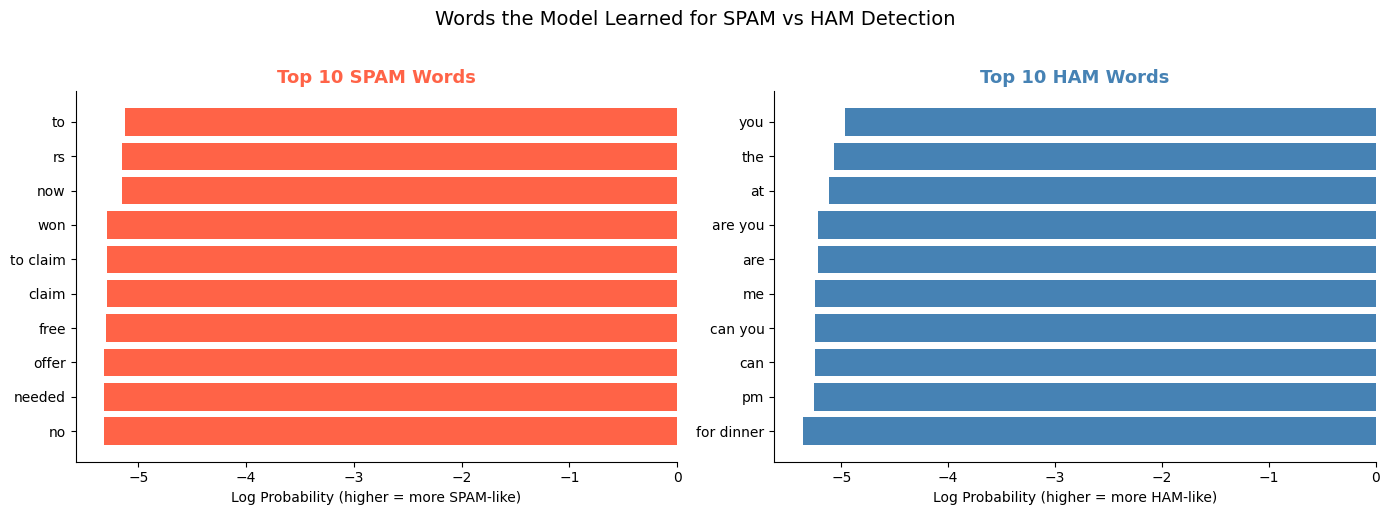

Chart saved as spam_ham_words.png


In [23]:
# ============================================================
# VISUALIZATION — Top SPAM words vs Top HAM words
# ============================================================
# Let's see which words the model thinks are most SPAM-like

# Get all feature (word) names from TF-IDF
feature_names = tfidf.get_feature_names_out()

# Naive Bayes stores the log probability of each feature for each class
# .feature_log_prob_ has shape (num_classes, num_features)
# Row 0 = HAM class, Row 1 = SPAM class
# Higher value = word is more associated with that class
log_probs = model.feature_log_prob_

# SPAM log probabilities = row 1
spam_probs = log_probs[1]  # Index 1 = SPAM class
# HAM log probabilities = row 0
ham_probs  = log_probs[0]  # Index 0 = HAM class

# Get indices of top 10 SPAM words (highest spam probability)
# argsort() sorts and gives us the indices
# [-10:] takes the last 10 (highest values)
# [::-1] reverses so highest is first
top_spam_idx = spam_probs.argsort()[-10:][::-1]
top_ham_idx  = ham_probs.argsort()[-10:][::-1]

# Get the actual word names for these indices
top_spam_words = [feature_names[i] for i in top_spam_idx]
top_ham_words  = [feature_names[i] for i in top_ham_idx]

# Get their scores (higher = more associated with that class)
top_spam_scores = [spam_probs[i] for i in top_spam_idx]
top_ham_scores  = [ham_probs[i] for i in top_ham_idx]

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SPAM words bar chart
# [::-1] reverses the order so highest bar is at the top
axes[0].barh(top_spam_words[::-1], top_spam_scores[::-1], color='tomato')
axes[0].set_title('Top 10 SPAM Words', fontsize=13, fontweight='bold', color='tomato')
axes[0].set_xlabel('Log Probability (higher = more SPAM-like)')
axes[0].spines['top'].set_visible(False)    # Remove top border
axes[0].spines['right'].set_visible(False)  # Remove right border

# HAM words bar chart
axes[1].barh(top_ham_words[::-1], top_ham_scores[::-1], color='steelblue')
axes[1].set_title('Top 10 HAM Words', fontsize=13, fontweight='bold', color='steelblue')
axes[1].set_xlabel('Log Probability (higher = more HAM-like)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Overall title for the whole figure
plt.suptitle('Words the Model Learned for SPAM vs HAM Detection', fontsize=14, y=1.02)

# tight_layout() makes sure nothing overlaps
plt.tight_layout()

# Save the chart as an image file
plt.savefig('spam_ham_words.png', dpi=120, bbox_inches='tight')
plt.show()
print("Chart saved as spam_ham_words.png")

In [24]:
# ============================================================
# BONUS: Compare BoW vs TF-IDF performance
# Which one gives better accuracy for spam detection?
# ============================================================

results = []  # We will store results here

# List of configurations to try
# Each configuration is: (name, vectorizer, model)
configs = [
    # Config 1: BoW (CountVectorizer) with Naive Bayes
    ('BoW + Naive Bayes',      CountVectorizer(),                      MultinomialNB()),
    # Config 2: BoW with bigrams
    ('BoW Bigrams + NB',       CountVectorizer(ngram_range=(1,2)),     MultinomialNB()),
    # Config 3: TF-IDF with Naive Bayes
    ('TF-IDF + Naive Bayes',   TfidfVectorizer(),                      MultinomialNB()),
    # Config 4: TF-IDF with bigrams
    ('TF-IDF Bigrams + NB',    TfidfVectorizer(ngram_range=(1,2)),     MultinomialNB()),
    # Config 5: TF-IDF with Logistic Regression
    ('TF-IDF + Log Regression',TfidfVectorizer(ngram_range=(1,2)),     LogisticRegression(max_iter=1000)),
]

# Re-create the original split for fair comparison
X_all = df['Cleaned_Message']
y_all = df['Label']
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

print("Comparing different approaches:")
print("=" * 50)
print(f"{'Approach':<30} {'Accuracy'}")
print("-" * 45)

for name, vec, clf in configs:
    # Vectorize
    X_tr_vec = vec.fit_transform(X_tr)  # Fit and transform training data
    X_te_vec = vec.transform(X_te)      # Only transform test data

    # Train
    clf.fit(X_tr_vec, y_tr)  # Train the model

    # Predict
    preds = clf.predict(X_te_vec)  # Make predictions

    # Measure
    acc = accuracy_score(y_te, preds)  # Calculate accuracy
    results.append((name, acc))

    # Print a bar made of blocks to show accuracy visually
    bar = '█' * int(acc * 20)  # 20 blocks = 100%, so each block = 5%
    print(f"{name:<30} {acc:.2%}  {bar}")

# Find the best result
# max() with key= tells it to compare by the second item in each tuple (the accuracy)
best_name, best_acc = max(results, key=lambda x: x[1])
print()
print(f"✅ Best approach: {best_name} with {best_acc:.2%} accuracy")

Comparing different approaches:
Approach                       Accuracy
---------------------------------------------
BoW + Naive Bayes              100.00%  ████████████████████
BoW Bigrams + NB               100.00%  ████████████████████
TF-IDF + Naive Bayes           100.00%  ████████████████████
TF-IDF Bigrams + NB            100.00%  ████████████████████
TF-IDF + Log Regression        100.00%  ████████████████████

✅ Best approach: BoW + Naive Bayes with 100.00% accuracy


In [25]:
# ============================================================
# 🏋️ PRACTICE — Type ANY message and check if it's spam!
# ============================================================

# ✏️ Change this message and run the cell!
your_message = "You have been selected to receive a FREE gift worth Rs 10000!"

# ✏️ Add more messages to test (just add to the list)
more_messages = [
    "Hey, can we talk later today?",
    "Call now to claim your prize, limited time offer!",
    "I will meet you at the library at 4pm",
]

all_test = [your_message] + more_messages

print("Your Spam Detector Results:")
print("=" * 60)
print()

for msg in all_test:
    result = classify_message(msg)
    emoji = '🚫 SPAM' if result == 'SPAM' else '✅ HAM '
    print(f"{emoji} | {msg}")
    print()

Your Spam Detector Results:

🚫 SPAM | You have been selected to receive a FREE gift worth Rs 10000!

✅ HAM  | Hey, can we talk later today?

🚫 SPAM | Call now to claim your prize, limited time offer!

✅ HAM  | I will meet you at the library at 4pm



---
---
# 📝 Phase 2 — Complete Summary

## What You Learned

| Topic | What it does | Key Code |
|-------|-------------|----------|
| **Bag of Words** | Counts word occurrences | `CountVectorizer()` |
| **TF-IDF** | Scores words by importance | `TfidfVectorizer()` |
| **N-grams** | Captures word phrases | `ngram_range=(1,2)` |
| **Train/Test Split** | Fair model evaluation | `train_test_split()` |
| **Naive Bayes** | Fast text classifier | `MultinomialNB()` |
| **Accuracy** | Measures performance | `accuracy_score()` |

---

## Key Rules to Remember
1. Always `fit_transform()` on TRAINING data only
2. Always `transform()` (not fit) on TEST data
3. TF-IDF is usually better than BoW for most tasks
4. Use `ngram_range=(1,2)` as your default — captures phrases
5. Naive Bayes is a great starting model for text classification

---

## BoW vs TF-IDF — When to Use Which?

| Use BoW when... | Use TF-IDF when... |
|-----------------|-------------------|
| Word frequency matters | Word importance matters |
| Short documents | Long documents |
| Simple tasks | Most NLP tasks |

---

## 🚀 What's Next? — Phase 3
In Phase 3, we dive into **Word Embeddings**:
- **Word2Vec** — words become dense vectors (not just counts!)
- **GloVe** — pre-trained vectors from billions of words
- **FastText** — handles typos and new words
- **Cosine Similarity** — find how similar two texts are

---
*You built a real spam detector from scratch! That's Phase 2 complete. 💪*

*Keep practicing with the CampusX NLP Playlist 🎓*